# Impact of shredding on galaxy measurements

Makes the three Section 5 figures of the shredding paper:
- **`mass_metal_shred.pdf`** -- stellar mass vs. gas-phase metallicity (S22 calibration), shredded vs. corrected
- **`shred_size_mass_plot.pdf`** -- size--mass relation + per-object $\Delta$size vs. $\Delta$mag
- **`ncounts_relative_shred.pdf`** -- relative galaxy number counts (BGS Bright)

FastSpecFit matches are cached on pscratch (`iron_fastspec_catalog/shreds_cat/`) and regenerated if missing.

In [1]:
import os
import sys
import glob
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.lines import Line2D
from astropy.table import Table, vstack, Column
import astropy.units as u
from astropy.coordinates import SkyCoord

sys.path.append('/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code')
from plot_style import (apply_paper_style, make_subplots, reshape_axes,
                        MARGIN_LABEL, MARGIN_TICKS, MARGIN_PAD,
                        MARGIN_SHARED, MARGIN_SPLIT, MARGIN_CBAR)
apply_paper_style()

# Figures are written directly into the shredding-paper repo (git-tracked).
FIG_DIR = "/global/homes/v/virajvm/desi_papers/Dwarf_Fragmentation_Paper/figures"

# Shared DESI sample palette (same as catalog paper)
sample_colors = {"BGS_BRIGHT": "#882255", "BGS_FAINT": "#CC6677",
                 "LOWZ": "#DDCC77", "ELG": "#88CCEE"}

from astropy.cosmology import Planck18
from easyquery import Query, QueryMaker

from consolidate_photometry import (consolidate_new_photo, consolidate_positions_and_shapes,
                                    make_catalog_unmasked)
from shred_photometry_maskbits import create_shred_maskbits_from_dict
from desi_lowz_funcs import (get_stellar_mass_mia, match_fastspec_catalog, get_contours,
                             _n_or_more_lt, get_remove_flag)
import nebular_stuff.sfr_and_metallicity as sam
sam.line_flux_type = "FLUX"  # Gaussian-fit line fluxes, as in the original metallicity module
from nebular_stuff.sfr_and_metallicity import get_metallicity_P16, get_metallicity_S22

data_dir = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs"
fspec_save_path = f"{data_dir}/iron_fastspec_catalog/shreds_cat"

## Load reprocessed (shredded) catalogs

In [2]:
def get_fastspec_matched_catalog(gal_cat, save_name, match_method="TARGETID"):
    """TARGETID-matched FastSpecFit catalog, cached on pscratch."""
    fastspec_cat = match_fastspec_catalog(gal_cat, coord_name="", match_method=match_method)
    fastspec_cat = make_catalog_unmasked(fastspec_cat)
    fastspec_cat.write(f"{fspec_save_path}/{save_name}", overwrite=True)
    print(f"{np.sum(np.isnan(fastspec_cat['RA']))}/{len(fastspec_cat)} objects have no FastSpecFit match")
    return fastspec_cat


def add_mstars(cat, old_cols=("MAG_G", "MAG_R"), new_cols=("MAG_G_BEST", "MAG_R_BEST")):
    """Attach LOG_MSTAR_M24_OLD / _NEW columns from original and best photometry."""
    g_o, r_o = cat[old_cols[0]].data, cat[old_cols[1]].data
    cat["LOG_MSTAR_M24_OLD"] = get_stellar_mass_mia(g_o - r_o, g_o, cat["Z_CMB"].data,
                                                    d_in_mpc=cat["DIST_MPC_FIDU"].data, input_zred=False)
    g_n, r_n = cat[new_cols[0]].data, cat[new_cols[1]].data
    cat["LOG_MSTAR_M24_NEW"] = get_stellar_mass_mia(g_n - r_n, g_n, cat["Z_CMB"].data,
                                                    d_in_mpc=cat["DIST_MPC_FIDU"].data, input_zred=False)
    return cat


def load_reprocessed(sample, samp_type):
    """Reprocessed (shred/SGA) catalog with consolidated photometry, masses, and z<0.1 shred cut."""
    cat = Table.read(f"{data_dir}/iron_photometry/iron_{sample}_{samp_type}_catalog_w_aper_mags.fits")
    cat = consolidate_new_photo(cat, sample=sample, add_pcnn=False)
    cat = add_mstars(cat)
    cat = cat[(cat["FRACFLUX_G"] > 0.2) & (cat["FRACFLUX_R"] > 0.2) & (cat["FRACFLUX_Z"] > 0.2) & (cat["Z"] < 0.1)]
    cat["RA_TARGET"], cat["DEC_TARGET"] = cat["RA"].copy(), cat["DEC"].copy()
    return cat


samples = [("BGS_BRIGHT", "shreds"), ("SGA", "sga"), ("BGS_FAINT", "shreds"),
           ("ELG", "shreds"), ("LOWZ", "shreds")]
reproc = {s: load_reprocessed(s, t) for s, t in samples}

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.24278906445949336
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.062353
MASKBIT=2^2, bad resid, fraction : 0.0061
MASKBIT=2^3, cog curve decrease, fraction: 0.0104
MASKBIT=2^4, aperfrac-in image, fraction: 0.001104
MASKBIT=2^5, aperfrac-mask image, fraction: 0.051116
MASKBIT=2^6, image-frac mask, fraction: 0.000853
MASKBIT=2^7, bad colors, fraction: 0.000301
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.106847
MASKBIT=2^10, aper-cen masked, fraction: 0.052571
MASKBIT=2^11, no seg found, fraction: 0.000050
MASKBIT=2^12, near sga outskirts, fraction: 0.014547
Fraction of sources where org trac is likely good = 0.24278906445949336
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect som

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.24937067337948396
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0011
MASKBIT=2^1, cog not converge, fraction: 0.030050
MASKBIT=2^2, bad resid, fraction : 0.0019
MASKBIT=2^3, cog curve decrease, fraction: 0.0035
MASKBIT=2^4, aperfrac-in image, fraction: 0.005979
MASKBIT=2^5, aperfrac-mask image, fraction: 0.002203
MASKBIT=2^6, image-frac mask, fraction: 0.000315
MASKBIT=2^7, bad colors, fraction: 0.000629
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.021554
MASKBIT=2^10, aper-cen masked, fraction: 0.005979
MASKBIT=2^11, no seg found, fraction: 0.000000
Fraction of sources where org trac is likely good = 0.24937067337948396
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect some objects reverted to original Tractor photometry
MAS

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.3164933135215453
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0104
MASKBIT=2^1, cog not converge, fraction: 0.082912
MASKBIT=2^2, bad resid, fraction : 0.0128
MASKBIT=2^3, cog curve decrease, fraction: 0.0074
MASKBIT=2^4, aperfrac-in image, fraction: 0.000297
MASKBIT=2^5, aperfrac-mask image, fraction: 0.128975
MASKBIT=2^6, image-frac mask, fraction: 0.001189
MASKBIT=2^7, bad colors, fraction: 0.000594
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.111738
MASKBIT=2^10, aper-cen masked, fraction: 0.112927
MASKBIT=2^11, no seg found, fraction: 0.000000
MASKBIT=2^12, near sga outskirts, fraction: 0.006241
Fraction of sources where org trac is likely good = 0.3164933135215453
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect some 

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.1904447644188465
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.1785
MASKBIT=2^1, cog not converge, fraction: 0.033057
MASKBIT=2^2, bad resid, fraction : 0.0024
MASKBIT=2^3, cog curve decrease, fraction: 0.0013
MASKBIT=2^4, aperfrac-in image, fraction: 0.000340
MASKBIT=2^5, aperfrac-mask image, fraction: 0.190725
MASKBIT=2^6, image-frac mask, fraction: 0.001320
MASKBIT=2^7, bad colors, fraction: 0.001120
MASKBIT=2^8, source not on segment, fraction: 0.0041
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.043177
MASKBIT=2^10, aper-cen masked, fraction: 0.016699
MASKBIT=2^11, no seg found, fraction: 0.030218
MASKBIT=2^12, near sga outskirts, fraction: 0.005720
Fraction of sources where org trac is likely good = 0.1904447644188465
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect some 

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.5136911281489595
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0088
MASKBIT=2^1, cog not converge, fraction: 0.185104
MASKBIT=2^2, bad resid, fraction : 0.0022
MASKBIT=2^3, cog curve decrease, fraction: 0.0110
MASKBIT=2^4, aperfrac-in image, fraction: 0.000000
MASKBIT=2^5, aperfrac-mask image, fraction: 0.024096
MASKBIT=2^6, image-frac mask, fraction: 0.000000
MASKBIT=2^7, bad colors, fraction: 0.000000
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.096386
MASKBIT=2^10, aper-cen masked, fraction: 0.020811
MASKBIT=2^11, no seg found, fraction: 0.000000
MASKBIT=2^12, near sga outskirts, fraction: 0.002191
Fraction of sources where org trac is likely good = 0.5136911281489595
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect some 

## Mass--metallicity relation

In [3]:
def mzr_arrays(sample):
    """(mstar_old, OH_old) for all shreds and (mstar_new, OH_new) for PHOTO_MASKBIT==0 subset."""
    cat = reproc[sample]
    cache = f"{fspec_save_path}/{sample}_cat.fits"
    if os.path.exists(cache):
        fspec = Table.read(cache)
    else:
        fspec = get_fastspec_matched_catalog(cat, f"{sample}_cat.fits", match_method="TARGETID")

    oh_s22, snr_mask = get_metallicity_S22(fspec)
    cat_f = cat[snr_mask]
    good = cat_f["PHOTO_MASKBIT"].data == 0
    return (cat_f["LOG_MSTAR_M24_OLD"].data, oh_s22,
            cat_f["LOG_MSTAR_M24_NEW"].data[good], oh_s22[good])


mzr = {s: mzr_arrays(s) for s, _ in samples}
mstar_shred_all = np.concatenate([mzr[s][0] for s, _ in samples])
oh_shred_all = np.concatenate([mzr[s][1] for s, _ in samples])
mstar_new_all = np.concatenate([mzr[s][2] for s, _ in samples])
oh_new_all = np.concatenate([mzr[s][3] for s, _ in samples])

Satisyfing line snr+ratio mask = 0.25258726539203646


  0%|          | 0/2880 [00:00<?, ?it/s]

  2%|▏         | 69/2880 [00:00<00:04, 685.11it/s]

  5%|▍         | 139/2880 [00:00<00:03, 691.07it/s]

  7%|▋         | 209/2880 [00:00<00:03, 694.82it/s]

...

 99%|█████████▉| 2381/2405 [00:03<00:00, 650.17it/s]

100%|██████████| 2405/2405 [00:03<00:00, 648.85it/s]

Satisyfing line snr+ratio mask = 0.06280193236714976


  0%|          | 0/13 [00:00<?, ?it/s]

100%|██████████| 13/13 [00:00<00:00, 738.94it/s]

In [4]:
def process_clean_cat():
    """Robust (clean) catalog with S22 metallicities, via cached FastSpecFit match."""
    clean_cat = Table.read(f"{data_dir}/desi_y1_dwarf_clean_catalog_v4.fits")
    clean_cat = clean_cat[clean_cat["Z"] < 0.1]
    clean_maskbits = create_shred_maskbits_from_dict(clean_cat, bitmasks_to_apply=[7, 12, 13, 14, 15],
                                                     verbose=True, mag_type="")
    clean_cat = clean_cat[clean_maskbits == 0]

    gr = clean_cat["MAG_G"].data - clean_cat["MAG_R"].data
    clean_cat["LOG_MSTAR_M24"] = get_stellar_mass_mia(gr, clean_cat["MAG_G"].data, clean_cat["Z_CMB"].data,
                                                      d_in_mpc=clean_cat["DIST_MPC_FIDU"].data, input_zred=False)
    clean_cat["RA_TARGET"], clean_cat["DEC_TARGET"] = clean_cat["RA"].copy(), clean_cat["DEC"].copy()

    cache = f"{fspec_save_path}/clean_cat_cat.fits"
    if os.path.exists(cache):
        clean_fspec = Table.read(cache)
    else:
        clean_fspec = get_fastspec_matched_catalog(clean_cat, "clean_cat_cat.fits", match_method="TARGETID")

    oh_s22, snr_mask = get_metallicity_S22(clean_fspec)
    clean_f = clean_cat[snr_mask]
    clean_f["O/H_S22"] = oh_s22
    return clean_f


clean_cat = process_clean_cat()

MASKBIT=2^7, bad colors, fraction: 0.000008
MASKBIT=2^12, near sga outskirts, fraction: 0.004449
MASKBIT=2^13, bad rchisq, fraction: 0.000000
MASKBIT=2^14, low snr, fraction: 0.000999
MASKBIT=2^15, Tractor maskbit flagged: 0.0240


Satisyfing line snr+ratio mask = 0.21146544553069174


  0%|          | 0/51351 [00:00<?, ?it/s]

  0%|          | 69/51351 [00:00<01:14, 686.66it/s]

  0%|          | 141/51351 [00:00<01:12, 704.11it/s]

...

 99%|█████████▉| 51071/51351 [01:14<00:00, 707.89it/s]

100%|█████████▉| 51143/51351 [01:14<00:00, 709.50it/s]

100%|█████████▉| 51217/51351 [01:14<00:00, 715.57it/s]

100%|█████████▉| 51289/51351 [01:14<00:00, 713.67it/s]

100%|██████████| 51351/51351 [01:15<00:00, 684.51it/s]

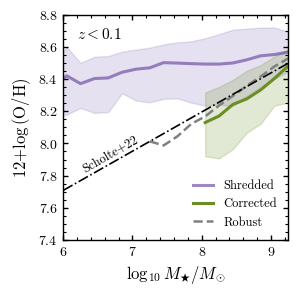

In [5]:
def scholte22_rel(mstar):
    Z0, gamma, beta, m0 = 8.864, 0.2439, 1.20, 10 ** 10.49
    return Z0 - (gamma / beta) * np.log10(1 + (mstar / m0) ** (-beta))


bins_mzr = np.arange(5.75, 9.7, 0.2)
conts_shred = get_contours(mstar_shred_all, oh_shred_all, bins=bins_mzr, min_count=30, sigs=True)
conts_new = get_contours(mstar_new_all, oh_new_all, bins=bins_mzr, min_count=30, sigs=True)
conts_clean_s22 = get_contours(clean_cat["LOG_MSTAR_M24"].data, clean_cat["O/H_S22"], bins=bins_mzr,
                               min_count=30, sigs=True)

fig, ax = make_subplots(ncol=1, nrow=1, return_fig=True, plot_size=2.25,
                        col_spacing=[MARGIN_LABEL, MARGIN_PAD],
                        row_spacing=[MARGIN_LABEL, MARGIN_PAD])

lw = 2.2
ax[0].plot(conts_shred["bin_cents"], conts_shred["median"], color="#5D3A9B", lw=lw, label="Shredded", alpha=0.6)
ax[0].fill_between(x=conts_shred["bin_cents"], y1=conts_shred["sig1_high"], y2=conts_shred["sig1_low"],
                   color="#5D3A9B", alpha=0.15)
ax[0].plot(conts_new["bin_cents"], conts_new["median"], color="olivedrab", lw=lw, label="Corrected")
ax[0].fill_between(x=conts_new["bin_cents"], y1=conts_new["sig1_high"], y2=conts_new["sig1_low"],
                   color="olivedrab", alpha=0.2)
ax[0].plot(conts_clean_s22["bin_cents"], conts_clean_s22["median"], color="grey", ls="--", lw=1.8, label="Robust")

mgrid = np.logspace(5.75, 9.25, 100)
ax[0].plot(np.log10(mgrid) + 0.25, scholte22_rel(mgrid), color="k", ls="-.", lw=1.2)
ax[0].text(6.25, 7.825, "Scholte+22", rotation=30, fontsize=9, color="k")

ax[0].set_xlim([6, 9.25])
ax[0].set_ylim([7.4, 8.8])
ax[0].set_ylabel(r"12+$\log$(O/H)")
ax[0].set_xlabel(r"$\log_{10}M_{\bigstar}/M_{\odot}$")
ax[0].legend(loc="lower right", fontsize=9, handlelength=1.6)
ax[0].text(6.2, 8.65, r"$z < 0.1$", color="k")

plt.savefig(f"{FIG_DIR}/mass_metal_shred.pdf")
plt.show()

## Size--mass relation

In [6]:
def size_arrays(sample):
    """Sizes (kpc): shredded (SHAPE_R) vs corrected (R50_R, PHOTO_MASKBIT==0), and the good-subset catalog."""
    cat = reproc[sample]

    d_a = Planck18.angular_diameter_distance(cat["Z_CMB"]).value * 1000 / 206265
    r12_kpc_old = d_a * cat["SHAPE_R"].data
    mstar_old = cat["LOG_MSTAR_M24_OLD"].data

    good = cat[cat["PHOTO_MASKBIT"] == 0]
    good = consolidate_positions_and_shapes(good)
    d_a_g = Planck18.angular_diameter_distance(good["Z_CMB"]).value * 1000 / 206265
    r12_kpc_new = d_a_g * good["R50_R"].data
    mstar_new = good["LOG_MSTAR_M24_NEW"].data

    return mstar_old, r12_kpc_old, mstar_new, r12_kpc_new, good


sizes = {s: size_arrays(s) for s, _ in samples}
mstar_shred_all_s = np.concatenate([sizes[s][0] for s, _ in samples])
size_shred_all = np.concatenate([sizes[s][1] for s, _ in samples])
mstar_new_all_s = np.concatenate([sizes[s][2] for s, _ in samples])
size_new_all = np.concatenate([sizes[s][3] for s, _ in samples])

# per-object size & magnitude changes for the right panel
all_size_diffs, all_mag_diffs = [], []
for s, _ in samples:
    cati = sizes[s][4]
    cati = cati[cati["SHAPE_R"].data > 0]
    all_size_diffs.append(np.log10(cati["R50_R"].data) - np.log10(cati["SHAPE_R"].data))
    all_mag_diffs.append(cati["MAG_R_BEST"].data - cati["MAG_R"].data)
all_size_diffs = np.concatenate(all_size_diffs)
all_mag_diffs = np.concatenate(all_mag_diffs)

Adding the consolidated RA,DEC, and SHAPE columns


  0%|          | 0/9640 [00:00<?, ?it/s]

100%|██████████| 9640/9640 [00:00<00:00, 351968.55it/s]

  0%|          | 0/9640 [00:00<?, ?it/s]

100%|██████████| 9640/9640 [00:00<00:00, 356873.82it/s]

...

  0%|          | 0/189 [00:00<?, ?it/s]

100%|██████████| 189/189 [00:00<00:00, 307495.52it/s]

  0%|          | 0/189 [00:00<?, ?it/s]

100%|██████████| 189/189 [00:00<00:00, 299933.20it/s]

Consolidated RA, DEC, and SHAPE_PARAMS columns added. Added PHOTOMETRY_UPDATED column


In [7]:
def process_cat_size_clean():
    clean_cat = Table.read(f"{data_dir}/desi_y1_dwarf_clean_catalog_v4.fits")
    clean_cat = clean_cat[clean_cat["Z"] < 0.1]
    clean_maskbits = create_shred_maskbits_from_dict(clean_cat, bitmasks_to_apply=[7, 12, 13, 14, 15],
                                                     verbose=True, mag_type="")
    clean_cat = clean_cat[clean_maskbits == 0]

    gr = clean_cat["MAG_G"].data - clean_cat["MAG_R"].data
    mstar = get_stellar_mass_mia(gr, clean_cat["MAG_G"].data, clean_cat["Z_CMB"].data,
                                 d_in_mpc=clean_cat["DIST_MPC_FIDU"].data, input_zred=False)
    d_a = Planck18.angular_diameter_distance(clean_cat["Z_CMB"]).value * 1000 / 206265
    return mstar, d_a * clean_cat["SHAPE_R"].data


mstar_clean_all, size_clean_all = process_cat_size_clean()

MASKBIT=2^7, bad colors, fraction: 0.000008
MASKBIT=2^12, near sga outskirts, fraction: 0.004449
MASKBIT=2^13, bad rchisq, fraction: 0.000000
MASKBIT=2^14, low snr, fraction: 0.000999
MASKBIT=2^15, Tractor maskbit flagged: 0.0240


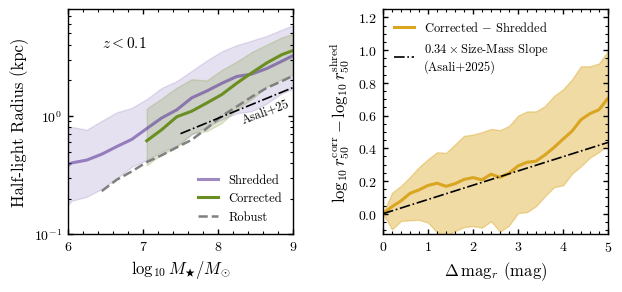

In [8]:
bins_sz = np.arange(5.75, 9.5, 0.2)
conts_size_shred = get_contours(mstar_shred_all_s[size_shred_all > 0],
                                np.log10(size_shred_all[size_shred_all > 0]), bins=bins_sz, min_count=30, sigs=True)
conts_size_new = get_contours(mstar_new_all_s[size_new_all > 0],
                              np.log10(size_new_all[size_new_all > 0]), bins=bins_sz, min_count=30, sigs=True)
conts_size_clean = get_contours(mstar_clean_all[size_clean_all > 0],
                                np.log10(size_clean_all[size_clean_all > 0]), bins=bins_sz, min_count=30, sigs=True)

fig, ax = make_subplots(ncol=2, nrow=1, return_fig=True, plot_size=2.25,
                        col_spacing=[MARGIN_LABEL, MARGIN_LABEL, MARGIN_PAD],
                        row_spacing=[MARGIN_LABEL, MARGIN_PAD])

lw = 2.2
ax[0].plot(conts_size_shred["bin_cents"], 10 ** np.array(conts_size_shred["median"]),
           color="#5D3A9B", lw=lw, label="Shredded", alpha=0.6)
ax[0].fill_between(x=conts_size_shred["bin_cents"], y1=10 ** np.array(conts_size_shred["sig1_high"]),
                   y2=10 ** np.array(conts_size_shred["sig1_low"]), color="#5D3A9B", alpha=0.15)
ax[0].plot(conts_size_new["bin_cents"], 10 ** np.array(conts_size_new["median"]),
           color="olivedrab", lw=lw, label="Corrected")
ax[0].fill_between(x=conts_size_new["bin_cents"], y1=10 ** np.array(conts_size_new["sig1_high"]),
                   y2=10 ** np.array(conts_size_new["sig1_low"]), color="olivedrab", alpha=0.2)
ax[0].plot(conts_size_clean["bin_cents"], 10 ** np.array(conts_size_clean["median"]),
           color="grey", ls="--", label="Robust", lw=1.8)

mgrid = np.linspace(7.5, 9.5)
ax[0].plot(mgrid, 10 ** (0.26 * mgrid - 2.10), color="k", ls="-.", lw=1.2)
ax[0].text(8.3, 10 ** -0.065, "Asali+25", rotation=20, fontsize=9, color="k")

ax[0].set_xlim([6, 9])
ax[0].set_ylim([0.1, 8])
ax[0].set_yscale("log")
ax[0].set_ylabel("Half-light Radius (kpc)")
ax[0].set_xlabel(r"$\log_{10}M_{\bigstar}/M_{\odot}$")
ax[0].legend(loc="lower right", fontsize=9, handlelength=1.6)
ax[0].text(0.25, 0.85, r"$z < 0.1$", color="k", transform=ax[0].transAxes, ha="center", va="center")

conts_diff = get_contours(-1 * all_mag_diffs, all_size_diffs, bins=np.arange(-0.1, 5.5, 0.2), sigs=True)

color = "goldenrod"
ax[1].plot(conts_diff["bin_cents"], conts_diff["median"], color=color, lw=lw, label=r"Corrected $-$ Shredded")
ax[1].fill_between(x=conts_diff["bin_cents"], y1=conts_diff["sig1_high"], y2=conts_diff["sig1_low"],
                   color=color, alpha=0.4)

xgrid = np.linspace(0, 5, 100)
ax[1].plot(xgrid, 0.335 * 0.26 * xgrid, color="k", ls="-.", lw=1.2,
           label="$0.34\\times$" + "Size-Mass Slope\n(Asali+2025)")

ax[1].legend(loc="upper left", fontsize=9, handlelength=1.6)
ax[1].set_xlim([0, 5])
ax[1].set_ylim([-0.125, 1.25])
ax[1].set_xlabel(r"$\Delta\,$mag$_r$ (mag)")
ax[1].set_ylabel(r"$\log_{10}r^{\rm corr}_{50} - \log_{10}r^{\rm shred}_{50} $")

plt.savefig(f"{FIG_DIR}/shred_size_mass_plot.pdf")
plt.show()

## Relative galaxy number counts (BGS Bright)

In [9]:
def process_cat_counts(sample, samp_type):
    """Clean + reprocessed + SGA catalogs stacked, with old/new masses and the likely-shred mask."""
    keep = ["Z", "MAG_G", "MAG_R", "MAG_Z", "MAG_G_BEST", "MAG_R_BEST", "MAG_Z_BEST",
            "FRACFLUX_G", "FRACFLUX_R", "FRACFLUX_Z", "PHOTO_MASKBIT", "Z_CMB", "DIST_MPC_FIDU"]

    clean_cat = Table.read(f"{data_dir}/desi_y1_dwarf_clean_catalog_v4.fits")
    clean_cat = clean_cat[clean_cat["SAMPLE"] == sample]
    for b in "GRZ":
        clean_cat[f"MAG_{b}_BEST"] = clean_cat[f"MAG_{b}"].copy()
    clean_cat["PHOTO_MASKBIT"] = np.zeros(len(clean_cat))
    clean_cat = clean_cat[keep]

    shred_cat = Table.read(f"{data_dir}/iron_photometry/iron_{sample}_{samp_type}_catalog_w_aper_mags.fits")
    shred_cat = consolidate_new_photo(shred_cat, sample=sample, add_pcnn=False)[keep]

    sga_cat = Table.read(f"{data_dir}/iron_photometry/iron_SGA_sga_catalog_w_aper_mags.fits")
    sga_cat = consolidate_new_photo(sga_cat, sample="SGA", add_pcnn=False)
    sga_cat = sga_cat[sga_cat["SAMPLE_DESI"] == sample][keep]

    tot_cat = vstack([clean_cat, shred_cat, sga_cat])

    gr = tot_cat["MAG_G"].data - tot_cat["MAG_R"].data
    tot_cat["LOG_M24_OLD"] = get_stellar_mass_mia(gr, tot_cat["MAG_G"].data, tot_cat["Z_CMB"].data,
                                                  d_in_mpc=tot_cat["DIST_MPC_FIDU"].data, input_zred=False)
    gr = tot_cat["MAG_G_BEST"].data - tot_cat["MAG_R_BEST"].data
    tot_cat["LOG_M24_NEW"] = get_stellar_mass_mia(gr, tot_cat["MAG_G_BEST"].data, tot_cat["Z_CMB"].data,
                                                  d_in_mpc=tot_cat["DIST_MPC_FIDU"].data, input_zred=False)

    fracflux_grz = [f"FRACFLUX_{b}" for b in "GRZ"]
    shred_queries = [Query(_n_or_more_lt(fracflux_grz, 2, 0.2))]
    shred_mask = get_remove_flag(tot_cat, shred_queries) == 0
    return tot_cat, shred_mask


bgsb_tot_cat, bgsb_shred_mask = process_cat_counts("BGS_BRIGHT", "shreds")
bgsb_clean = bgsb_tot_cat[~bgsb_shred_mask]

mstars_ff_cut = bgsb_clean["LOG_M24_OLD"].data
mstars_tot = bgsb_tot_cat["LOG_M24_OLD"].data
mstars_tot_f = np.concatenate([mstars_ff_cut,
                               bgsb_tot_cat[bgsb_shred_mask & (bgsb_tot_cat["PHOTO_MASKBIT"] == 0)]["LOG_M24_NEW"].data])

bins = np.arange(5.75, 9.5, 0.25)
bin_cens = 0.5 * (bins[1:] + bins[:-1])
ff_counts, _ = np.histogram(mstars_ff_cut, bins=bins)
tot_counts, _ = np.histogram(mstars_tot, bins=bins)
tot_counts_f, _ = np.histogram(mstars_tot_f, bins=bins)

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.24278906445949336
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0030
MASKBIT=2^1, cog not converge, fraction: 0.062353
MASKBIT=2^2, bad resid, fraction : 0.0061
MASKBIT=2^3, cog curve decrease, fraction: 0.0104
MASKBIT=2^4, aperfrac-in image, fraction: 0.001104
MASKBIT=2^5, aperfrac-mask image, fraction: 0.051116
MASKBIT=2^6, image-frac mask, fraction: 0.000853
MASKBIT=2^7, bad colors, fraction: 0.000301
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.106847
MASKBIT=2^10, aper-cen masked, fraction: 0.052571
MASKBIT=2^11, no seg found, fraction: 0.000050
MASKBIT=2^12, near sga outskirts, fraction: 0.014547
Fraction of sources where org trac is likely good = 0.24278906445949336
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect som

Not adding the PCNN values! Adding all 1.
FRACTION REVERT BACK TO TRACTOR: 0.24937067337948396
Need to include the VI column that only does the aperture no subtract photo
Adding the photo maskbits
MASKBIT=2^0, cog nan mask, 0.0011
MASKBIT=2^1, cog not converge, fraction: 0.030050
MASKBIT=2^2, bad resid, fraction : 0.0019
MASKBIT=2^3, cog curve decrease, fraction: 0.0035
MASKBIT=2^4, aperfrac-in image, fraction: 0.005979
MASKBIT=2^5, aperfrac-mask image, fraction: 0.002203
MASKBIT=2^6, image-frac mask, fraction: 0.000315
MASKBIT=2^7, bad colors, fraction: 0.000629
MASKBIT=2^8, source not on segment, fraction: 0.0000
MASKBIT=2^9, within star mask radius and not just a simple blend, fraction: 0.021554
MASKBIT=2^10, aper-cen masked, fraction: 0.005979
MASKBIT=2^11, no seg found, fraction: 0.000000
Fraction of sources where org trac is likely good = 0.24937067337948396
Adding bit=0 for tractor_og type!
Updating the maskbits to reflect some objects reverted to original Tractor photometry
MAS

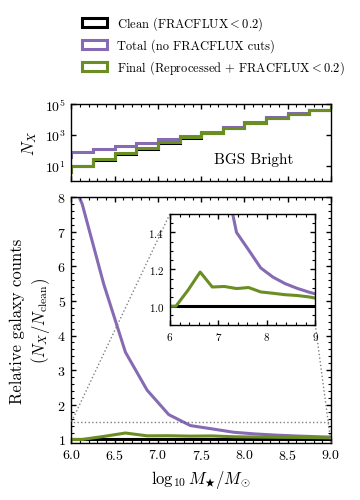

In [10]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

fig, (ax_hist, ax_main) = plt.subplots(
    2, 1, figsize=(3.35, 4.4), sharex=True,
    gridspec_kw={"height_ratios": [1.25, 4], "hspace": 0.1})

lw = 2.2
ax_hist.hist(mstars_ff_cut, bins=bins, histtype="step", color="k", lw=lw, label="Clean (FRACFLUX$<$0.2)")
ax_hist.hist(mstars_tot, bins=bins, histtype="step", color="#5D3A9B", lw=lw,
             label="Total (no FRACFLUX cuts)", alpha=0.75)
ax_hist.hist(mstars_tot_f, bins=bins, histtype="step", color="olivedrab", lw=lw,
             label="Final (Reprocessed + FRACFLUX$<$0.2)")

ax_hist.set_ylabel("$N_X$")
ax_hist.set_yscale("log")
ax_hist.set_ylim([1, 1e5])
ax_hist.set_yticks([1e1, 1e3, 1e5])

fig.legend(handles=ax_hist.get_lines(), labels=[l.get_label() for l in ax_hist.get_lines()],
           loc="upper center", bbox_to_anchor=(0.55, 1.11), ncol=1, frameon=False, fontsize=9)

ax_main.plot(bin_cens, ff_counts / ff_counts, color="k", lw=lw)
ax_main.plot(bin_cens, tot_counts / ff_counts, color="#5D3A9B", lw=lw, alpha=0.75)
ax_main.plot(bin_cens, tot_counts_f / ff_counts, color="olivedrab", lw=lw)

ax_main.set_xlim([6, 9])
ax_main.set_ylim([0.9, 8])
ax_main.set_ylabel("Relative galaxy counts\n" + r"($N_X/N_{\mathrm{clean}}$)")
ax_main.set_xlabel(r"$\log_{10}M_{\bigstar}/M_{\odot}$")

ax_inset = inset_axes(ax_main, width="140%", height="150%",
                      bbox_to_anchor=(0.35, 0.45, 0.4, 0.3),
                      bbox_transform=ax_main.transAxes, loc="lower left")
ax_inset.plot(bin_cens, ff_counts / ff_counts, color="k", lw=lw)
ax_inset.plot(bin_cens, tot_counts / ff_counts, color="#5D3A9B", lw=lw, alpha=0.75)
ax_inset.plot(bin_cens, tot_counts_f / ff_counts, color="olivedrab", lw=lw)
ax_inset.set_xlim([6, 9])
ax_inset.set_ylim([0.9, 1.5])
ax_inset.set_xticks([6, 7, 8, 9])
ax_inset.tick_params(labelsize=8)
mark_inset(ax_main, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5", ls="dotted")

ax_hist.text(0.55, 0.28, "BGS Bright", transform=ax_hist.transAxes, weight="bold", va="center")

plt.savefig(f"{FIG_DIR}/ncounts_relative_shred.pdf", bbox_inches="tight")
plt.show()